# Prediction of Heavy Metal Concentrations (Pb, Cd)

### Overview

This notebook presents a machine learning experiment designed within a Data Stewardship framework, focusing on the prediction of missing environmental variables using existing observational data. The dataset consists of precipitation chemistry measurements collected across Austria, including ion concentrations and selected heavy metals such as Lead (Pb) and Cadmium (Cd).

Due to incomplete spatial and temporal coverage, measurements of Pb and Cd are not available for all observations. This experiment addresses this limitation by training machine learning models to estimate these missing values based on other chemical and environmental variables.


**Source** 

*Concentrations of major ions in wet precipitation samples in Austria*

https://researchdata.tuwien.ac.at/records/b0g4h-rv840

### Authors and Contacts
- Federico Ambrogi, 01449911@student.tuwien.ac.at
- Amin Saad Rashidul 
- Farooq Mian Azan
- Vijayalakshmi Puthenpurayil Biju 

### Imports

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.models import *
from src.evaluation import *
from src.utils import *

from sklearn.model_selection import train_test_split
import pandas as pd

### Load and Prepare Data

In [ ]:
# Loading precipitation data into a pandas dataframe 
# Will try DBRepo
# Else from Local File 
# (Useful for comaprison and debugging) 

try:
    # Loading from DBRepo
    df: pd.DataFrame = load_data(path=False)
    print('Loaded DBRepo data')
    # Loading from local csv
except Exception as err:
    csv_path = "../data/precipitationdata.csv"
    print('Failed DBRepo, Loaded CSV data')
    df: pd.DataFrame = load_data(path=csv_path)
    
print(df.head(3))


# Forcing DBRepo loading
df: pd.DataFrame = load_data(path=False)

In [ ]:
# Data Cleaning and selecting features 
df = clean_dataframe(df)
df = feature_engineering(df)

features = prepare_features(df)

In [11]:
# Create output directories
out_fig_dir = '../outputs/figures/'
if not os.path.isdir(out_fig_dir):
    os.makedirs(out_fig_dir)  
    print(" *** Created folder : ", out_fig_dir)

out_mod_dir = '../outputs/models/'
if not os.path.isdir(out_mod_dir):
    os.makedirs(out_mod_dir)
    print(" *** Created folder : ", out_mod_dir)

Loaded CSV data
        Datum Ort   NS  NS_flag     LF  LF_flag    pH  pH_flag    NH4  \
0  2014-10-01  SO  6.7      1.0   4.05      1.0  5.52      1.0  0.158   
1  2014-10-01  AF  1.4      1.0  16.95      1.0  5.72      1.0  1.187   
2  2014-10-01  LI  3.8      1.0    NaN      7.0   NaN      7.0    NaN   

   NH4_flag  ...     Cl  Cl_flag    NO3  NO3_flag    SO4  SO4_flag       Pb  \
0       1.0  ...  0.016      1.0  0.493       1.0  0.573       1.0  0.00017   
1       1.0  ...  0.105      1.0  4.417       1.0  1.424       1.0      NaN   
2       7.0  ...    NaN      7.0    NaN       7.0    NaN       7.0      NaN   

   Pb_flag        Cd  Cd_flag  
0      1.0  0.032874      1.0  
1      7.0       NaN      7.0  
2      7.0       NaN      7.0  

[3 rows x 28 columns]


### Pb from Sequential Approach

{'rmse': 0.23645176053042874, 'mae': 0.07070812127761528}


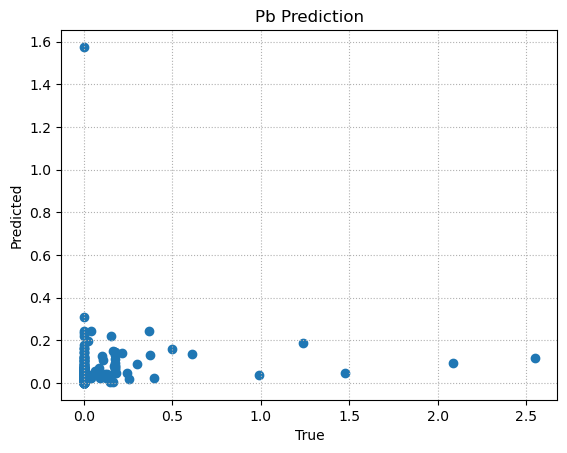

In [3]:
# ---- Pb ----
df_pb = df.dropna(subset=["Pb"])

X_pb = df_pb[features]
y_pb = df_pb["Pb"]

X_train_pb, X_test_pb, y_train_pb, y_test_pb = train_test_split(
    X_pb, y_pb, test_size=0.2, random_state=42
)

#model_pb = train_pb_model(X_train_pb, y_train_pb)
model_pb = train_model(X_train_pb, y_train_pb)

'''
model_pb = train_model(X_train_pb, y_train_pb)
model_cd = train_model(X_train_cd, y_train_cd)
model_multi = train_model(X_train_m, y_train_m)
'''

y_pred_pb = model_pb.predict(X_test_pb)

metrics_pb = compute_metrics(y_test_pb, y_pred_pb)


print(metrics_pb)

    

    
plot_prediction(
    y_test_pb, y_pred_pb,
    "Pb Prediction",
    "../outputs/figures/fig_pb_prediction.png"
)

### Cd from Sequential Model 
 

{'rmse': 0.14199312508423387, 'mae': 0.04678229361582522}


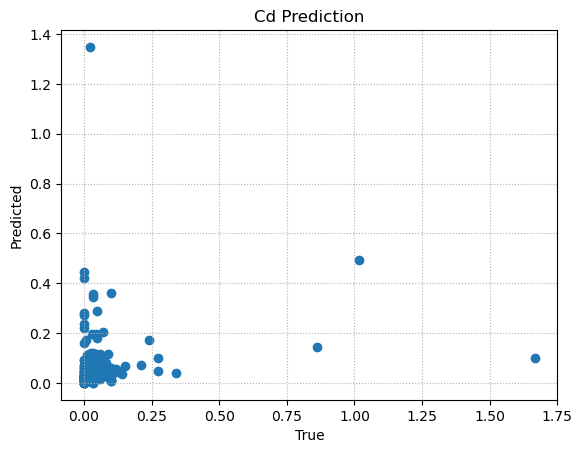

In [4]:
df_cd = df.dropna(subset=["Cd"])

X_cd_base = df_cd[features]
predicted_pb = model_pb.predict(X_cd_base)

X_cd = X_cd_base.copy()
X_cd["Pb_predicted"] = predicted_pb

y_cd = df_cd["Cd"]


X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(
    X_cd, y_cd, test_size=0.2, random_state=42
)

#model_cd = train_cd_model(X_train_cd, y_train_cd)

model_cd = train_model(X_train_cd, y_train_cd)
save_model(model_cd, "../outputs/models/model_cd_randomforest.pkl")

y_pred_cd = model_cd.predict(X_test_cd)

metrics_cd = compute_metrics(y_test_cd, y_pred_cd)

print(metrics_cd)

plot_prediction(
    y_test_cd, y_pred_cd,
    "Cd Prediction",
    "../outputs/figures/fig_cd_prediction.png"
)


### Multi-output

In [5]:
df_multi = df.dropna(subset=["Pb", "Cd"])

X_multi = df_multi[features]
Y_multi = df_multi[["Pb", "Cd"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, Y_multi, test_size=0.2, random_state=42
)


model_multi = train_model(X_train_m, y_train_m)
# saving model 
save_model(model_multi, "../outputs/models/model_multi_randomforest.pkl")


y_pred_m = model_multi.predict(X_test_m)

y_pred_cd_m = y_pred_m[:, 1]

metrics_multi = compute_metrics(y_test_m["Cd"], y_pred_cd_m)


In [6]:
# Metric Values

for metric in metrics_multi.items():
    print('Metric: ' , metric)

Metric:  ('rmse', 0.12941772556729142)
Metric:  ('mae', 0.04250304511045665)


### Feature Importance

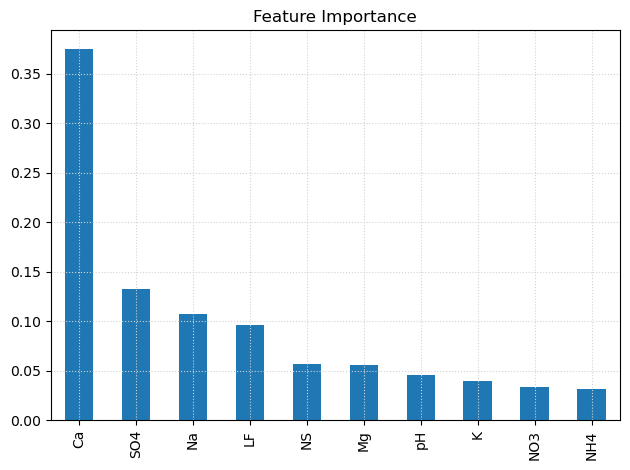

In [7]:
plot_feature_importance(
    model_pb,
    X_pb.columns,
    "../outputs/figures/fig_feature_importance_pb.png"
)